In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("D:\mca_aiml_lab\mca_env\Datasets\dm_office_sales.csv")
df

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_10656\1389830471.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df=pd.read_csv("D:\mca_aiml_lab\mca_env\Datasets\dm_office_sales.csv")


,division,level of education,training level,work experience,salary,sales
0,printers,some college,2,6,91684,372302
1,printers,associate's degree,2,10,119679,495660
2,peripherals,high school,0,9,82045,320453
3,office supplies,associate's degree,2,5,92949,377148
4,office supplies,high school,1,5,71280,312802
...,...,...,...,...,...,...
995,computer hardware,associate's degree,1,1,70083,177953
996,computer software,associate's degree,1,0,68648,103703
997,peripherals,associate's degree,2,8,108354,450011
998,peripherals,associate's degree,2,3,79035,330354


In [4]:
df.head()

,division,level of education,training level,work experience,salary,sales
0,printers,some college,2,6,91684,372302
1,printers,associate's degree,2,10,119679,495660
2,peripherals,high school,0,9,82045,320453
3,office supplies,associate's degree,2,5,92949,377148
4,office supplies,high school,1,5,71280,312802


In [5]:
df.shape

(1000, 6)

In [7]:
X=df.iloc[:,:-1] #.values
y=df.iloc[:,-1] #.values #turn df to NumPy array


In [6]:
X

,division,level of education,training level,work experience,salary
0,printers,some college,2,6,91684
1,printers,associate's degree,2,10,119679
2,peripherals,high school,0,9,82045
3,office supplies,associate's degree,2,5,92949
4,office supplies,high school,1,5,71280
...,...,...,...,...,...
995,computer hardware,associate's degree,1,1,70083
996,computer software,associate's degree,1,0,68648
997,peripherals,associate's degree,2,8,108354
998,peripherals,associate's degree,2,3,79035


In [7]:
X.shape

(1000, 5)

In [8]:
y

0      372302
1      495660
2      320453
3      377148
4      312802
        ...  
995    177953
996    103703
997    450011
998    330354
999    364436
Name: sales, Length: 1000, dtype: int64

In [8]:
y.shape  , X.shape

((1000,), (1000, 5))

In [ ]:
#help(train_test_split)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
#if we want to compare multiple ml models, they must have same train/test split, 
# random state =same no ensures it.

In [12]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((670, 5), (670,), (330, 5), (330,))

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
encoder=OneHotEncoder(sparse_output=False,drop='first')
#drop=first to avoid dummy variable trap
scaler=StandardScaler()

encoder


,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [14]:
X_train

,division,level of education,training level,work experience,salary
703,printers,some college,1,3,69827
311,office supplies,associate's degree,0,7,96135
722,printers,some college,1,5,85711
629,printers,associate's degree,1,4,73192
0,printers,some college,2,6,91684
...,...,...,...,...,...
106,printers,associate's degree,1,7,96834
270,printers,high school,1,2,58603
860,computer hardware,high school,3,4,95202
435,peripherals,high school,3,9,105047


In [17]:
#fit OHE categorical columns for X_train
encoder.fit(X_train[['division','level of education']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [18]:
#Scale numeric values column wise for X_train
scaler.fit(X_train[['training level','work experience','salary']])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [19]:
#once you fit OHE encoder and scaler on X_train, use it to get transformed X_train vectors
encoded_data_ohe=encoder.transform(X_train[['division','level of education']])

In [20]:
encoded_data_ohe

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(670, 8))

In [21]:
X_train_numeric_scaled=scaler.transform(X_train[['training level','work experience','salary']])

In [22]:
X_train_numeric_scaled.shape

X_train_numeric_scaled

array([[-0.2808703 , -1.03291352, -1.18099949],
       [-1.36238237,  0.31545873,  0.3446694 ],
       [-0.2808703 , -0.35872739, -0.25984529],
       ...,
       [ 1.88215384, -0.69582045,  0.29056232],
       [ 1.88215384,  0.98964486,  0.8614993 ],
       [-0.2808703 , -1.70709964, -1.46951259]], shape=(670, 3))

In [23]:
#to concatenate column-wise 2 numpy arrays
X_train_scaled=np.hstack((encoded_data_ohe,X_train_numeric_scaled))

In [25]:
X_train_scaled.shape

X_train_scaled


array([[ 0.        ,  0.        ,  0.        , ..., -0.2808703 ,
        -1.03291352, -1.18099949],
       [ 0.        ,  1.        ,  0.        , ..., -1.36238237,
         0.31545873,  0.3446694 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.2808703 ,
        -0.35872739, -0.25984529],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.88215384,
        -0.69582045,  0.29056232],
       [ 0.        ,  0.        ,  1.        , ...,  1.88215384,
         0.98964486,  0.8614993 ],
       [ 0.        ,  1.        ,  0.        , ..., -0.2808703 ,
        -1.70709964, -1.46951259]], shape=(670, 11))

In [ ]:
# OR using concatenate
#X_train_transf = np.concatenate((encoded_data_ohe, X_train_numeric_scaled), axis=1)

In [26]:
# Now repeat same steps for X_Test
#for deployment you will get Test data separately
encoded_data_ohe_test=encoder.transform(X_test[['division','level of education']])
X_test_numeric_scaled=scaler.transform(X_test[['training level','work experience','salary']])
X_test_scaled=np.hstack((encoded_data_ohe_test,X_test_numeric_scaled))


In [27]:
X_test_scaled.shape

(330, 11)

In [28]:
y_train.shape, y_test.shape
#it means flat set of 670 values in y_train 
# and 330 values in y_test

((670,), (330,))

In [29]:
scaler_y=StandardScaler()
y_train_scaled=scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled=scaler_y.transform(y_test.values.reshape(-1,1))   
#here -1 is for 1 column, and -1 is for auto rows, 
# as we have only 1 column in y_train and y_test
#and we need to reshape it to 2D array for StandardScaler, as it expects 2D array input
#-1 represents the number of rows, and 1 represents the number of columns
#-1 is used when we want to automatically determine the number of rows 
# based on the original array size and the specified number of columns 
# (in this case, 1 column for y_train and y_test)

In [30]:
X_train_scaled.shape, y_train_scaled.shape, X_test_scaled.shape, y_test_scaled.shape

((670, 11), (670, 1), (330, 11), (330, 1))

In [31]:
import torch
#setup gpu device if available
device=torch.device("cpu")
if torch.cuda.is_available():
    device=torch.device("cuda") #gpu device
elif torch.backends.mps.is_available():
    device=torch.device("mps")  #mac gpu device
print("Using device:",device)

Using device: cpu


In [32]:
#Modern GPUs (RTX, A100, etc.) are heavily optimized for float32
#Double the memory usage
#float32: 4 bytes per param
#float64: 8 bytes per param → 2× model size
import torch
X_train_scaled=torch.tensor(X_train_scaled,dtype=torch.float32) 
X_test_scaled=torch.tensor(X_test_scaled,dtype=torch.float32)
#let's turn their dtype to float else nn won't accept them
y_train_scaled=torch.tensor(y_train_scaled,dtype=torch.float32)
y_test_scaled=torch.tensor(y_test_scaled,dtype=torch.float32)
#price_ten=torch.tensor(df['price'],dtype=torch.float32)

In [33]:
X_train_scaled.dtype,X_test_scaled.dtype,y_train_scaled.dtype,y_test_scaled.dtype

(torch.float32, torch.float32, torch.float32, torch.float32)

In [34]:
X_train_scaled.shape,y_train_scaled.shape,X_test_scaled.shape,y_test_scaled.shape

(torch.Size([670, 11]),
 torch.Size([670, 1]),
 torch.Size([330, 11]),
 torch.Size([330, 1]))

In [35]:
#defining your model architecture
from torch import nn
import torch
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear=nn.Linear(in_features=11,out_features=1) 
        #self.relu = nn.ReLU()
        #we have 11 input features 
        #we want to predict one output sales
        #self.weights=nn.Parameter(torch.randn(11,1,dtype=torch.float32),requires_grad=True)
        #self.bias=nn.Parameter(torch.randn(1,dtype=torch.float32),requires_grad=True)

    def forward(self,x):
        return self.linear(x)   
        #return self.relu(self.linear(x))   
#nn.Linear(11, 1) automatically creates and manages weights + biases
# our manual definitions are redundant.

In [36]:
model = LinearRegressionModel()
print(model.linear.weight.shape)  # torch.Size([1, 11])
print(model.linear.bias.shape)    # torch.Size([1])
print(model.linear.weight)        # Random values
print(model.linear.bias)          # ~0.0 values


torch.Size([1, 11])
torch.Size([1])
Parameter containing:
tensor([[-0.2555,  0.2743, -0.0800,  0.1686,  0.0423,  0.1472, -0.0399,  0.0925,
         -0.0162, -0.2714, -0.0432]], requires_grad=True)
Parameter containing:
tensor([0.2991], requires_grad=True)


In [37]:
#creating single neuron model
from torch import nn
#model=nn.Linear(2,1) #model accepts 2 inputs and one output
model=LinearRegressionModel() #model accepts 11 inputs and one output
loss_fn=torch.nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9)

In [38]:
#put model in evaluation/inference mode
#let's check the predictions before training
#how model does with random weights and bias
model.eval()
#stop tracking gradients
with torch.no_grad(): 
    y_pred=model(X_test_scaled)         
    print(y_pred)


tensor([[-0.5411],
        [-0.1555],
        [ 0.3761],
        [-0.1820],
        [ 0.0492],
        [-0.7697],
        [ 0.1687],
        [-0.3223],
        [ 0.4583],
        [ 0.5033],
        [-0.1725],
        [-0.6054],
        [-0.6773],
        [ 0.1945],
        [ 0.1285],
        [-0.3774],
        [ 0.1374],
        [-0.2101],
        [-0.7124],
        [ 0.5736],
        [-1.0669],
        [-0.4732],
        [-1.0260],
        [-0.0494],
        [ 0.4238],
        [ 0.2588],
        [-0.2516],
        [-0.2163],
        [ 0.2533],
        [-0.5788],
        [ 0.0496],
        [ 0.0257],
        [-0.1687],
        [ 0.3275],
        [ 0.0477],
        [ 0.0746],
        [ 0.0139],
        [-0.2886],
        [-0.5105],
        [-0.5175],
        [ 0.3040],
        [-0.1883],
        [-0.3965],
        [ 0.1999],
        [-0.4340],
        [ 0.5842],
        [-0.1536],
        [ 0.5243],
        [ 0.6667],
        [ 0.3044],
        [-0.3609],
        [-0.8104],
        [-0.

In [60]:
y_test_scaled

tensor([[ 1.0494],
        [ 0.4283],
        [-0.7401],
        [ 0.7679],
        [-0.0454],
        [ 1.1869],
        [-0.2984],
        [ 0.8416],
        [-0.3561],
        [-1.4912],
        [-0.2234],
        [ 0.7099],
        [ 1.1760],
        [-0.1509],
        [-0.4914],
        [ 1.1970],
        [-0.0938],
        [ 0.0352],
        [ 1.8587],
        [-1.0257],
        [ 1.5021],
        [ 2.2411],
        [ 1.9555],
        [ 0.5240],
        [-0.6329],
        [-1.3953],
        [ 0.7292],
        [-0.5321],
        [-1.6044],
        [ 0.6032],
        [-0.6630],
        [-0.6630],
        [-0.6618],
        [-1.1992],
        [ 0.2314],
        [-0.7848],
        [-0.6000],
        [ 0.1178],
        [ 0.9659],
        [ 0.1814],
        [-0.8617],
        [-0.2164],
        [ 1.4114],
        [ 0.3281],
        [ 0.7061],
        [-0.4055],
        [ 0.6472],
        [-0.9455],
        [-1.6543],
        [-0.9814],
        [ 0.9298],
        [ 2.1622],
        [-0.

In [39]:
# Convert model weights to float64 to avoid runtime error
#data tensors to float32 to match model weights dtype
#saying tensor X and model weight are of different types of float
#we get RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float
model = model.to(torch.float32)

In [40]:
#repeating training pass 1000 times
#this loop calculates loss for all 670 training samples 
# simultaneously in a single forward/backward pass per iteration.
for i in range(0,1000):
    optimizer.zero_grad() #zero out the gradients before backpropagation
    outputs=model(X_train_scaled) #forward pass to get predictions
    loss=loss_fn(outputs,y_train_scaled) 
    #calculate loss between predictions and true values
    loss.backward() #backpropagation to calculate gradients
    optimizer.step() #update weights and bias using calculated gradients
    if i%10==0:
        #print(model.bias)
        #print(model.weights)
        print(f'Epoch [{i+1}/100000], Loss: {loss.item()}') 
        #.item() to get scalar value from tensor
        # Print progress + current loss value every 10 epochs

Epoch [1/100000], Loss: 1.9975152015686035
Epoch [11/100000], Loss: 1.520704984664917
Epoch [21/100000], Loss: 0.8813995122909546
Epoch [31/100000], Loss: 0.47975897789001465
Epoch [41/100000], Loss: 0.2911560535430908
Epoch [51/100000], Loss: 0.21401704847812653
Epoch [61/100000], Loss: 0.1818591207265854
Epoch [71/100000], Loss: 0.16538652777671814
Epoch [81/100000], Loss: 0.15442243218421936
Epoch [91/100000], Loss: 0.1459103673696518
Epoch [101/100000], Loss: 0.13888312876224518
Epoch [111/100000], Loss: 0.1329001635313034
Epoch [121/100000], Loss: 0.12768128514289856
Epoch [131/100000], Loss: 0.12303584069013596
Epoch [141/100000], Loss: 0.1188378855586052
Epoch [151/100000], Loss: 0.11500521004199982
Epoch [161/100000], Loss: 0.11148291081190109
Epoch [171/100000], Loss: 0.10823222994804382
Epoch [181/100000], Loss: 0.10522394627332687
Epoch [191/100000], Loss: 0.10243476927280426
Epoch [201/100000], Loss: 0.09984523802995682
Epoch [211/100000], Loss: 0.09743866324424744
Epoch [2

In [41]:
#put model in evaluation/inference mode
model.eval()
#stop tracking gradients
with torch.no_grad(): 
    y_pred=model(X_test_scaled)         
    print(y_pred)

tensor([[ 1.1698e+00],
        [ 4.1856e-01],
        [-1.2124e+00],
        [ 5.3195e-01],
        [-1.9061e-01],
        [ 1.0611e+00],
        [ 6.3408e-04],
        [ 6.4732e-01],
        [-5.1208e-01],
        [-1.5166e+00],
        [ 9.7680e-02],
        [ 6.1106e-01],
        [ 1.2578e+00],
        [-3.0849e-01],
        [-5.4652e-01],
        [ 9.8735e-01],
        [ 6.4848e-02],
        [ 2.0167e-01],
        [ 1.9307e+00],
        [-1.2270e+00],
        [ 1.6324e+00],
        [ 2.0192e+00],
        [ 1.8508e+00],
        [ 4.9752e-01],
        [-7.8177e-01],
        [-1.0354e+00],
        [ 7.0356e-01],
        [-5.4875e-01],
        [-1.0924e+00],
        [ 4.9711e-01],
        [-6.5676e-01],
        [-4.1765e-01],
        [-4.9713e-01],
        [-9.4594e-01],
        [ 4.4989e-01],
        [-7.6524e-01],
        [-6.8901e-01],
        [ 1.5516e-01],
        [ 9.0986e-01],
        [ 1.7708e-01],
        [-9.7362e-01],
        [-3.3216e-01],
        [ 1.3248e+00],
        [ 2

In [42]:
y_test_scaled

tensor([[ 1.0494],
        [ 0.4283],
        [-0.7401],
        [ 0.7679],
        [-0.0454],
        [ 1.1869],
        [-0.2984],
        [ 0.8416],
        [-0.3561],
        [-1.4912],
        [-0.2234],
        [ 0.7099],
        [ 1.1760],
        [-0.1509],
        [-0.4914],
        [ 1.1970],
        [-0.0938],
        [ 0.0352],
        [ 1.8587],
        [-1.0257],
        [ 1.5021],
        [ 2.2411],
        [ 1.9555],
        [ 0.5240],
        [-0.6329],
        [-1.3953],
        [ 0.7292],
        [-0.5321],
        [-1.6044],
        [ 0.6032],
        [-0.6630],
        [-0.6630],
        [-0.6618],
        [-1.1992],
        [ 0.2314],
        [-0.7848],
        [-0.6000],
        [ 0.1178],
        [ 0.9659],
        [ 0.1814],
        [-0.8617],
        [-0.2164],
        [ 1.4114],
        [ 0.3281],
        [ 0.7061],
        [-0.4055],
        [ 0.6472],
        [-0.9455],
        [-1.6543],
        [-0.9814],
        [ 0.9298],
        [ 2.1622],
        [-0.

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#from sklearn.metrics import mean_absolute_error, mean_squared_error,root_mean_squared_error,r2_score
mean_absolute_error(y_test_scaled,y_pred)
mean_squared_error(y_test_scaled,y_pred)
#root_mean_squared_error(y_test,y_pred_original)
r2 = r2_score(y_test_scaled, y_pred)
print(f"R-squared: {r2:.3f}")
mse = mean_squared_error(y_test_scaled, y_pred)
print(f"MSE: {mse:.3f}")
print(f"MAE: {mean_absolute_error(y_test_scaled, y_pred):.3f}")

R-squared: 0.955
MSE: 0.046
MAE: 0.170


In [44]:
y_test_scaled.shape,y_pred.shape

(torch.Size([330, 1]), torch.Size([330, 1]))

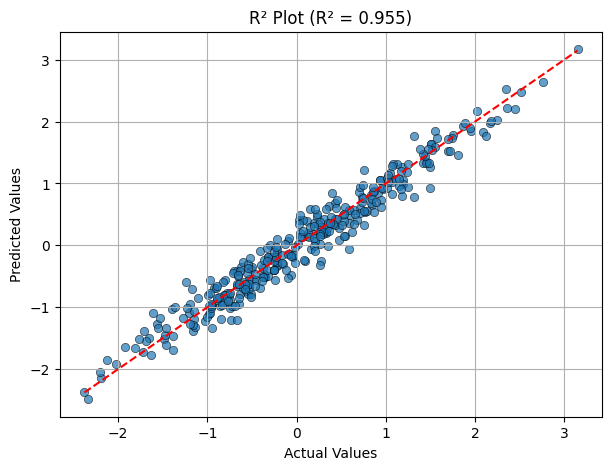

"'alpha=0.7 - Point transparency (0.7 = 70% opaque, \nprevents over-plotting when points overlap)\nedgecolor='k' - Black outline around each point\n(improves visibility/definition)\n"

In [45]:
''''Why .ravel()--our arrays were likely 2D (670,1) → 
flattened to 1D (670,) for plotting. 
Equivalent to .flatten() or .squeeze().'''
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test_scaled.ravel(), y=y_pred.ravel(), alpha=0.7, edgecolor='k')  
# Scatter plot of actual vs predicted
sns.lineplot(x=y_test_scaled.ravel(), y=y_test_scaled.ravel()   , color='red', linestyle='--')  
# Ideal 1:1 line

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"R² Plot (R² = {r2:.3f})")
plt.grid(True)
plt.show()
''''alpha=0.7 - Point transparency (0.7 = 70% opaque, 
prevents over-plotting when points overlap)
edgecolor='k' - Black outline around each point
(improves visibility/definition)
'''

In [46]:
# Descale predictions to original range
y_pred_original = scaler_y.inverse_transform(y_pred.detach().numpy())

'''detach() returns a new tensor that shares the same data but is no longer
connected to the autograd graph. After that, .numpy() can safely view 
that data as a NumPy array.
Without detach(), calling .numpy() on a grad-tracking tensor raises an error, 
and even if it didn’t, any further NumPy ops wouldn’t 
be tracked by autograd anyway.'''

'detach() returns a new tensor that shares the same data but is no longer\nconnected to the autograd graph. After that, .numpy() can safely view \nthat data as a NumPy array.\nWithout detach(), calling .numpy() on a grad-tracking tensor raises an error, \nand even if it didn’t, any further NumPy ops wouldn’t \nbe tracked by autograd anyway.'

In [47]:
y_test.shape,y_pred_original.shape

((330,), (330, 1))

In [48]:
y_pred_original

array([[463957.9  ],
       [382830.6  ],
       [206699.16 ],
       [395076.4  ],
       [317044.03 ],
       [452219.72 ],
       [337697.34 ],
       [407536.16 ],
       [282327.28 ],
       [173848.94 ],
       [348177.78 ],
       [403620.34 ],
       [473463.2  ],
       [304313.72 ],
       [278607.3  ],
       [444256.94 ],
       [344632.06 ],
       [359407.97 ],
       [546131.94 ],
       [205124.08 ],
       [513920.25 ],
       [555692.4  ],
       [537502.6  ],
       [391358.   ],
       [253202.1  ],
       [225813.62 ],
       [413609.8  ],
       [278367.06 ],
       [219654.   ],
       [391314.25 ],
       [266702.78 ],
       [292524.5  ],
       [283941.66 ],
       [235472.86 ],
       [386214.88 ],
       [254987.56 ],
       [263220.12 ],
       [354385.03 ],
       [435888.5  ],
       [356752.7  ],
       [232483.03 ],
       [301757.8  ],
       [480695.3  ],
       [360778.3  ],
       [394221.16 ],
       [262679.75 ],
       [399382.66 ],
       [23426

In [49]:
y_test

521    450963
737    383881
740    257699
660    420563
411    332728
        ...  
506    199582
342    266012
485    232183
711    433108
133    358205
Name: sales, Length: 330, dtype: int64